In [82]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using DifferentialEquations

In [83]:
# 1. Constants and Conversions
h = 6.626e-34       # Planck's constant (J*s)
c = 3e8             # Speed of light (m/s)
dB_to_linear = 4.343  #???

# Parameters from image
λp = 1480e-9
λs = 1550e-9
νp = c / λp
νs = c / λs

# dB/m to linear
αp = 3.0 / dB_to_linear
gp_star = 1.1 / dB_to_linear
αs = 3.3 / dB_to_linear
gs_star = 4.8 / dB_to_linear
ζ = 1.5e15  # m-1 s-1

Ap = (αp + gp_star) / ζ
As = (αs + gs_star) / ζ

Vp = 1/(h * νp)
Vs = 1/(h * νs)

# 2. Define the ODE System
# P[1] = Ps (Signal), P[2] = Pp (Pump)
function edfa_model!(dP, P, p, z)
    Ps, Pp = P
    
    S = -1 * (Vs*Ps*αs + Vp*Pp*αp) / (1 + Vs*Ps*As + Vp*Pp*Ap)
    
    # Explicit derivatives
    dP[1] = -Ps * (As*S + αs)
    dP[2] = -Pp * (Ap*S + αp)
    
    # Note: Simplified version for standard gain saturation models:
    # dP[1] = Ps * ( (gs_star + αs) * ( (Pp/(h*νp*ζ)) / (1 + Pp/(h*νp*ζ) + Ps/(h*νs*ζ)) ) - αs )
end

# 3. Execution
fiber_length = 50.0 # meters
signal_power = 100e-9  # 100 nW
pump_power = 4e-3  #pump_power

P0 = [signal_power, pump_power]
z_save = range(0.0, fiber_length, 100)
z_span = (0.0, fiber_length) # 10 meters

prob = ODEProblem(edfa_model!, P0, z_span)
sol = solve(prob, Tsit5(), reltol=1e-10, saveat=z_save);

print(sol.u)

[[1.0e-7, 0.004], [1.3102985048125219e-7, 0.003929320422259174], [1.7157179035060827e-7, 0.003858696845532173], [2.2453634984304526e-7, 0.003788128638307332], [2.9368356169212875e-7, 0.003717614461971804], [3.835872426959625e-7, 0.003647152307863475], [5.001924786161749e-7, 0.0035767389221721337], [6.520320281309869e-7, 0.00350636870895196], [8.503007258215075e-7, 0.003436033665505752], [1.1088554821717338e-6, 0.0033657233823849234], [1.4442615600251541e-6, 0.0032954250043705025], [1.87810644778554e-6, 0.003225121236391647], [2.4358885382539925e-6, 0.0031547908359208492], [3.1542394121563644e-6, 0.0030844021098419988], [4.083786626071638e-6, 0.0030139104674880676], [5.2891537124318436e-6, 0.0029432584206411094], [6.8489601795221895e-6, 0.0028723755835322585], [8.855821511480794e-6, 0.0028011786728417342], [1.1415464580948552e-5, 0.0027295731996317962], [1.466754824144103e-5, 0.002657433321903743], [1.881264449586822e-5, 0.002584573355610911], [2.4097104588989697e-5, 0.00251076820772018

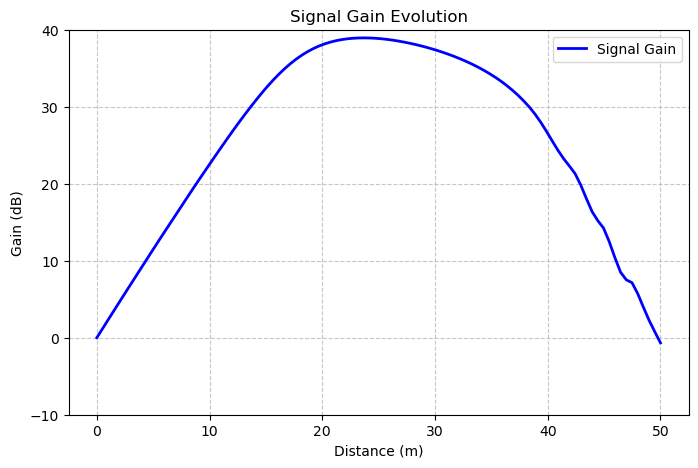

In [84]:
# 1. Extract data from the solution
z_vals = sol.t              
Ps_raw = [u[1] for u in sol.u] # Signal powers in Watts
Ps_raw = [max(0.0, u[1]) for u in sol.u] # Signal powers

# 2. Convert Signal to Gain (dB)
# Gain (dB) = 10 * log10(P_z / P_initial)
Ps_dB = 10 .* log10.(Ps_raw ./ signal_power) 

# 3. Create the plot
fig = figure(figsize=(8, 5))

# Plot Signal Gain only
plot(z_save, Ps_dB, label="Signal Gain", color="blue", linewidth=2)

# 4. Formatting
title("Signal Gain Evolution")
xlabel("Distance (m)")
ylabel("Gain (dB)") # Changed from Power (W) to Gain (dB)
ylim(-10, 40)
grid(true, linestyle="--", alpha=0.7)
legend()

fig

In [85]:
test = []
push!(test, Ps_raw);
push!(test, Ps_raw);
test

2-element Vector{Any}:
 [1.0e-7, 1.3102985048125219e-7, 1.7157179035060827e-7, 2.2453634984304526e-7, 2.9368356169212875e-7, 3.835872426959625e-7, 5.001924786161749e-7, 6.520320281309869e-7, 8.503007258215075e-7, 1.1088554821717338e-6  …  1.7693910624623097e-6, 1.0943742256088941e-6, 7.068957676677192e-7, 5.650473139287924e-7, 5.184948328095617e-7, 3.739842491612476e-7, 2.4931979336830666e-7, 1.6833318194683664e-7, 1.1944916925080117e-7, 8.583211008625429e-8]
 [1.0e-7, 1.3102985048125219e-7, 1.7157179035060827e-7, 2.2453634984304526e-7, 2.9368356169212875e-7, 3.835872426959625e-7, 5.001924786161749e-7, 6.520320281309869e-7, 8.503007258215075e-7, 1.1088554821717338e-6  …  1.7693910624623097e-6, 1.0943742256088941e-6, 7.068957676677192e-7, 5.650473139287924e-7, 5.184948328095617e-7, 3.739842491612476e-7, 2.4931979336830666e-7, 1.6833318194683664e-7, 1.1944916925080117e-7, 8.583211008625429e-8]

Same Length Diff Pump Power

In [86]:
pump_powers = [1 2 3 4 5 6 7 8 9 10] * 1e-3
signal_power = 100e-9
fiber_length = 50.0  #50 meters

z_save = range(0.0, fiber_length, 100)
z_span = (0.0, fiber_length)

power_out_dB = []

for pump_power in pump_powers
    P0 = [signal_power, pump_power]
    prob = ODEProblem(edfa_model!, P0, z_span)
    sol = solve(prob, Tsit5(), reltol=1e-10, saveat=z_save);

    # Ps_raw = [u[1] for u in sol.u] # Signal powers in Watts
    Ps_raw = [max(0.0, u[1]) for u in sol.u] # Negatives are zeros

    Ps_dB = 10 .* log10.(Ps_raw ./ signal_power) 

    push!(power_out_dB, Ps_dB);

end

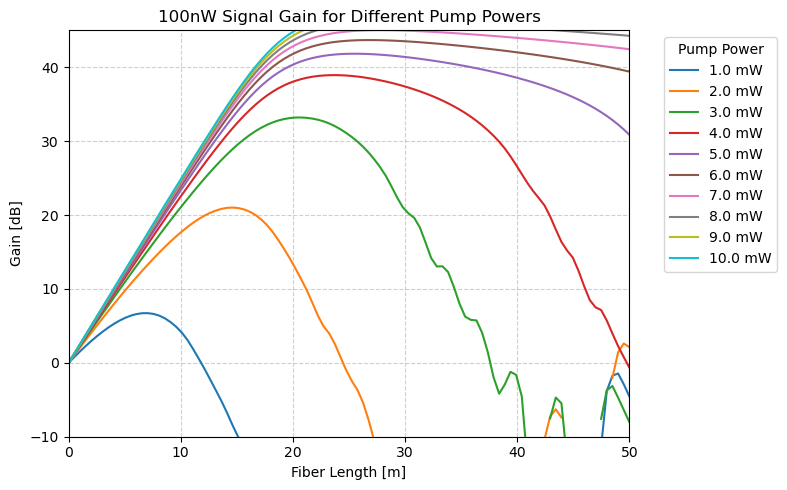

In [87]:
fig, ax = subplots(1, 1, figsize=(8, 5))

# Iterate through the results and the original pump powers
for i in 1:length(pump_powers)
    # Get the specific data for this pump power
    z_vals = sol.t # Note: this uses the z-steps from the last 'sol' in your loop
    gain_curve = power_out_dB[i]
    
    # Create a label (e.g., "1.0 mW")
    pump_label = @sprintf("%.1f mW", pump_powers[i] * 1e3)
    
    # Plot the curve
    ax.plot(z_save, gain_curve, label=pump_label)
end

# Formatting
ax.set_title("100nW Signal Gain for Different Pump Powers")
ax.set_xlabel("Fiber Length [m]")
ax.set_ylabel("Gain [dB]")
ax.grid(true, linestyle="--", alpha=0.6)
ax.legend(title="Pump Power", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.set_ylim(-10, 45)
ax.set_xlim(0, fiber_length)

fig.tight_layout()
fig

Same Power Different Lengths

In [92]:
pump_powers = range(0.0, 10.0, 30) * 1e-3
signal_power = 100e-9
fiber_lengths = [5.0, 10.0, 15.0, 20.0]  #50 meters

output = []

for fiber_length in fiber_lengths
    # z_save = range(0.0, fiber_length, 100)
    z_span = (0.0, fiber_length)

    power_out_dB = []

    for pump_power in pump_powers
        P0 = [signal_power, pump_power]
        prob = ODEProblem(edfa_model!, P0, z_span)
        sol = solve(prob, Tsit5(), reltol=1e-10);

        Ps_raw = [max(0.0, u[1]) for u in sol.u][end] # Negatives are zeros

        Ps_dB = 10 .* log10.(Ps_raw ./ signal_power) 

        push!(power_out_dB, Ps_dB);

    end
    push!(output, power_out_dB)
end 

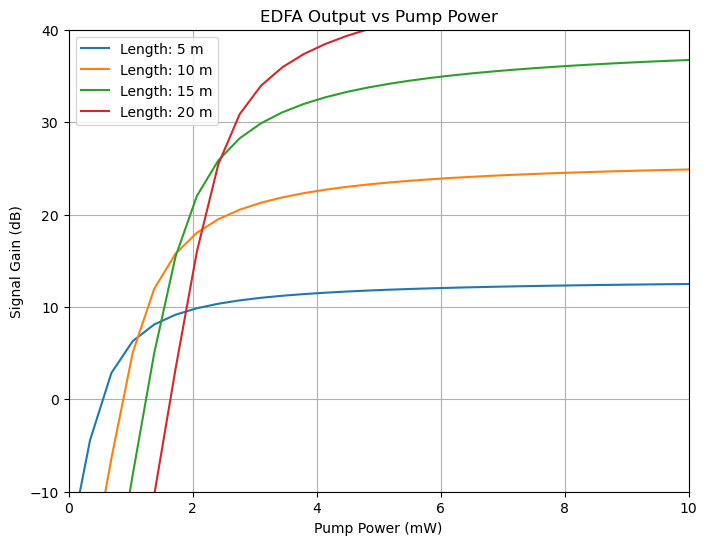

In [93]:
fig, ax = plt.subplots(figsize=(8, 6))

# Convert pump_powers to mW for a cleaner X-axis
pump_powers_mW = pump_powers .* 1e3

for (i, len) in enumerate(fiber_lengths)
    # output[i] contains the vector of Ps_dB for that specific length
    ax.plot(pump_powers_mW, output[i], label="Length: $(Int(len)) m")
end

ax.set_xlabel("Pump Power (mW)")
ax.set_ylabel("Signal Gain (dB)")
ax.set_title("EDFA Output vs Pump Power")
ax.grid(true)
ax.legend()
ax.set_ylim(-10, 40)
ax.set_xlim(0, pump_powers_mW[end])

fig